In [1]:
from sklearn.decomposition import PCA
import umap
import torch
import pandas as pd

## PCA reduction of Phoneme Output

We reverse the final output layer's weights. Instead of:

hidden (256) -> phonemes (50)

We take the phonemes and produce a 256-dimensional vector
representing each phoneme. Then we reduce to 3 dimensions using PCA.

In [28]:
from data_sb import make_encoders

# Recreate our encoder so we can put labels on the graph
hparams = {
    "word_outputs": 8000,
    "phone_outputs": 49,
    "supported_languages": ["fr", "en"],
    "word_files": {"fr": "data/words_fr.csv", "en": "data/words_en.csv"},
    "phon_files": {"fr": "data/phonemes_fr.csv", "en": "data/phonemes_en.csv"},
}
make_encoders(hparams)
phone_encoder = hparams["phon_encoder"]

In [3]:
def reduce_pca(model_file, phone_encoder, pca_components=3, normalize=False):
    """Takes a model file and produces a mapping from phoneme -> PCA components"""

    # Load model file and create phoneme -> hidden mapping, ignoring first "unk" token
    state_dict = torch.load(model_file, map_location="cpu")
    phone_mapping = state_dict["phone_out.weight"][1:]

    if normalize:
        phone_mapping = phone_mapping / phone_mapping.norm(dim=1, keepdim=True)

    # Reduce dimensions
    phone_pca = PCA(pca_components).fit_transform(phone_mapping)

    # Load labels and attach to component vectors
    phones = list(phone_encoder.lab2ind)[1:]
    phone2pca = [{"phoneme": p, **{f"pca_{i}": c for i, c in enumerate(pca)}} for p, pca in zip(phones, phone_pca)]

    return pd.DataFrame(phone2pca)

In [6]:
# Put everything together to generate phone2pca mapping
model_file = "bilingual_networks/results/20fr20fr05en95/save/CKPT+2025-11-18+17-41-19+00/model.ckpt"
phone2pca = reduce_pca(model_file, phone_encoder)

In [7]:
phone2pca.head()

,phoneme,pca_0,pca_1,pca_2
0,a,-0.581020,-0.419713,-0.461634
1,aw,-0.845667,-0.180932,-0.251910
2,aɪ,-0.552445,-0.592823,-0.612784
3,b,0.801171,-0.667767,0.744552
4,d,0.709532,-0.417653,0.141470


In [8]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'iframe'

fig = px.scatter_3d(phone2pca, x='pca_0', y='pca_1', z='pca_2', text='phoneme')
fig.show()

In [9]:
def reduce_umap(model_file, phone_encoder, umap_components=3, normalize=True):
    """Takes a model file and produces a mapping from phoneme -> UMAP components"""

    # Load model file and create phoneme -> hidden mapping, ignoring first "unk" token
    state_dict = torch.load(model_file, map_location="cpu")
    phone_mapping = state_dict["phone_out.weight"][1:]

    if normalize:
        phone_mapping = phone_mapping / phone_mapping.norm(dim=1, keepdim=True)

    # Reduce dimensions
    phone_umap = umap.UMAP(n_components=umap_components, metric='cosine').fit_transform(phone_mapping)

    # Load labels and attach to component vectors
    phones = list(phone_encoder.lab2ind)[1:]
    phone2umap = [{"phoneme": p, **{f"umap_{i}": c for i, c in enumerate(u)}} for p, u in zip(phones, phone_umap)]

    return pd.DataFrame(phone2umap)

In [10]:
model_file = "bilingual_networks/results/20fr20fr05en95/save/CKPT+2025-11-18+17-41-19+00/model.ckpt"
phone2umap = reduce_umap(model_file, phone_encoder)

In [11]:
#fig = px.scatter_3d(phone2umap, x='umap_0', y='umap_1', z='umap_2', text='phoneme')
fig = px.scatter(phone2umap, x='umap_0', y='umap_1', text='phoneme')
fig.update_traces(textposition='top center')
fig.show()

In [12]:
#model_file = "bilingual_networks/results/20fr20fr05en95/save/CKPT+2025-11-11+11-48-28+00/model.ckpt"
model_file = "bilingual_networks/results/20fr20en/save/CKPT+2025-11-18+17-57-24+00/model.ckpt"
phone2umap = reduce_umap(model_file, phone_encoder)

In [13]:
#fig = px.scatter_3d(phone2umap, x='umap_0', y='umap_1', z='umap_2', text='phoneme')
fig = px.scatter(phone2umap, x='umap_0', y='umap_1', text='phoneme')
fig.update_traces(textposition='top center')
fig.show()

In [14]:
# Looks like all the FR-only phonemes cluster at one side
fr_phonemes = set(pd.read_csv("data/phonemes_fr.csv")["homolog"])
en_phonemes = set(pd.read_csv("data/phonemes_en.csv")["homolog"])
fr_phonemes - en_phonemes

{'ø', 'œ', 'ɑ̃', 'ɔ̃', 'ɛ̃'}

In [13]:
# Weirdly, the cluster has a few extra phoenems, but maybe they're rare in the english data
# θ, 

In [15]:
model_file = "bilingual_networks/results/20fr20fr/save/CKPT+2025-11-18+17-39-20+00/model.ckpt"
phone2umap = reduce_umap(model_file, phone_encoder)

In [16]:
fig = px.scatter_3d(phone2umap, x='umap_0', y='umap_1', z='umap_2', text='phoneme')
fig = px.scatter(phone2umap, x='umap_0', y='umap_1', text='phoneme')
fig.update_traces(textposition='top center')
fig.show()

In [17]:
en_phonemes - fr_phonemes

{'aw', 'aɪ', 'ej', 'h', 'ow', 'æ', 'ð', 'ɚ', 'ɜ', 'ɪ', 'ʊ', 'ʌ', 'θ'}

In [17]:
# Likewise, there's a few shared phonemes in the cluster
# tʃ, 

In [18]:
frfr_confusions = torch.load("bilingual_networks/results/20fr20fr/confusions_test.txt")

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [20]:
### JUST NASALS
nasals = ['ɑ̃', 'ɔ̃', 'ɛ̃']
confusions = (frfr_confusions / (frfr_confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=3)
indexes = [phone_encoder.lab2ind[l] for l in nasals]
for nasal, accuracy in zip(nasals, confusions[indexes, indexes]):
    print(f"/{nasal}/ has accuracy {accuracy:.1%}")

/ɑ̃/ has accuracy 77.9%
/ɔ̃/ has accuracy 72.2%
/ɛ̃/ has accuracy 51.8%


In [21]:
fren_confusions = torch.load("bilingual_networks/results/20fr20en/confusions_test.txt")

In [23]:
### JUST NASALS
nasals = ['ɑ̃', 'ɔ̃', 'ɛ̃']
confusions = (fren_confusions / (fren_confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=3)
indexes = [phone_encoder.lab2ind[l] for l in nasals]
for nasal, accuracy in zip(nasals, confusions[indexes, indexes]):
    print(f"/{nasal}/ has accuracy {accuracy:.1%}")

/ɑ̃/ has accuracy 0.0%
/ɔ̃/ has accuracy 0.0%
/ɛ̃/ has accuracy 0.0%


In [24]:
frbi_confusions = torch.load("bilingual_networks/results/20fr20fr05en95/confusions_test.txt")

In [26]:
### JUST NASALS
nasals = ['ɑ̃', 'ɔ̃', 'ɛ̃']
confusions = (frbi_confusions / (frbi_confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=3)
indexes = [phone_encoder.lab2ind[l] for l in nasals]
for nasal, accuracy in zip(nasals, confusions[indexes, indexes]):
    print(f"/{nasal}/ has accuracy {accuracy:.1%}")

/ɑ̃/ has accuracy 71.2%
/ɔ̃/ has accuracy 57.3%
/ɛ̃/ has accuracy 32.8%


## Confusion Plots split by vowel-consonant

In [33]:
print(phone_encoder.ind2lab.values())

dict_values(['<unk>', 'a', 'aw', 'aɪ', 'b', 'd', 'dʒ', 'e', 'ej', 'f', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'ow', 'p', 'r', 's', 't', 'tʃ', 'u', 'v', 'w', 'z', 'æ', 'ð', 'ø', 'ŋ', 'œ', 'ɑ', 'ɑ̃', 'ɔ', 'ɔ̃', 'ə', 'ɚ', 'ɛ', 'ɛ̃', 'ɜ', 'ɡ', 'ɪ', 'ʃ', 'ʊ', 'ʌ', 'ʒ', 'θ'])


In [51]:
monophthongs = ['a', 'ʌ', 'ɑ', 'ɑ̃', 'æ', 'ɔ', 'ɔ̃', 'e', 'ə', 'ɚ', 'ɛ', 'ɛ̃', 'ɜ', 'ɪ', 'i', 'o', 'ø', 'œ', 'u', 'ʊ']
consonants = ['d', 'dʒ', 'ʒ', 't', 'tʃ', 'ʃ', 'ð', 'f', 'θ', 's', 'h', 'z', 'j', 'k', 'ɡ', 'b', 'p', 'l', 'm', 'n', 'ŋ', 'r', 'v', 'w']
vowel_rows = phone_encoder.encode_sequence(monophthongs)
conso_rows = phone_encoder.encode_sequence(consonants)
print(vowel_rows)

[1, 46, 33, 34, 28, 35, 36, 7, 37, 38, 39, 40, 41, 43, 11, 17, 30, 32, 24, 45]


In [52]:
import numpy as np

def plot_confusions(confusions, rows, labels, title_prefix=""):
    # Calculate appropriate figure size based on number of labels
    n_labels = len(labels)
    fig_size = max(6, n_labels * 0.4)  # Minimum 6 inches, scale with number of labels
    figure, ax = plt.subplots(figsize=(fig_size, fig_size))

    # Normalize by true label (dim 1) -- each true label adds up to 100% (across rows)
    confusions_pct = (confusions / (confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=2) * 100

    # Select the specified rows/columns
    sub_confusions = confusions_pct[np.ix_(rows, rows)]
    disp = ConfusionMatrixDisplay(sub_confusions, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, im_kw={'vmax': 80})  # Disable default colorbar
    
    # Add colorbar with custom size
    plt.colorbar(disp.im_, ax=ax, fraction=0.0455, pad=0.04)
    plt.title(f"{title_prefix} Confusion Rates (%)")
    plt.show()

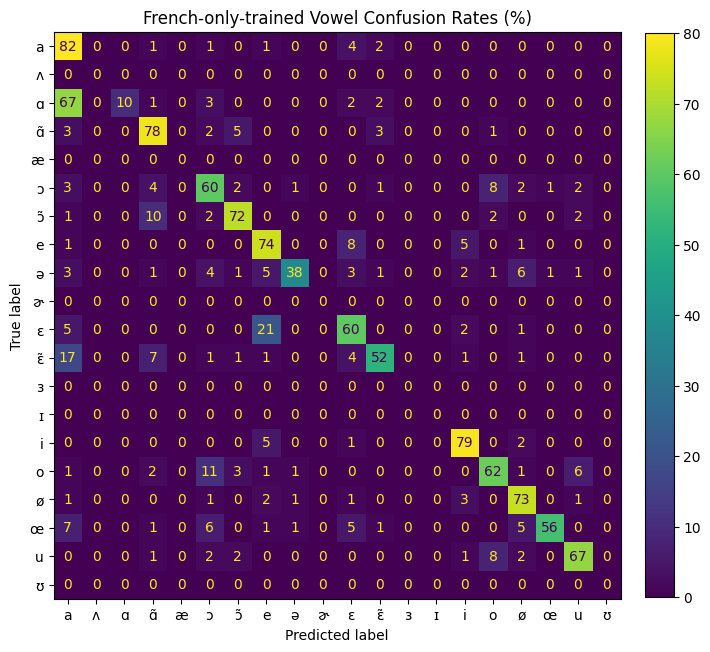

In [53]:
plot_confusions(frfr_confusions, vowel_rows, monophthongs, "French-only-trained Vowel")

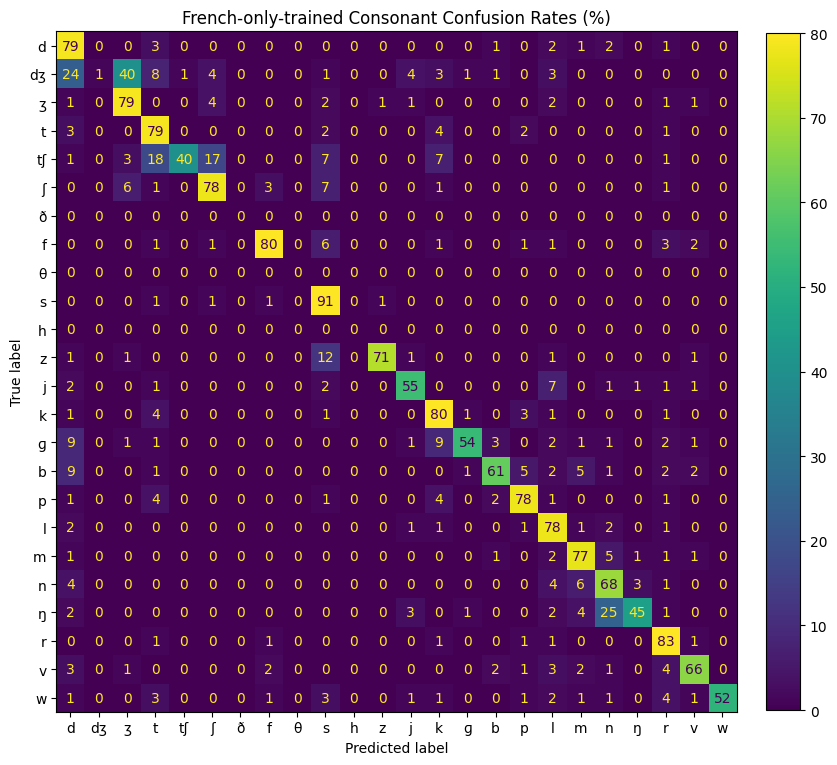

In [54]:
plot_confusions(frfr_confusions, conso_rows, consonants, "French-only-trained Consonant")

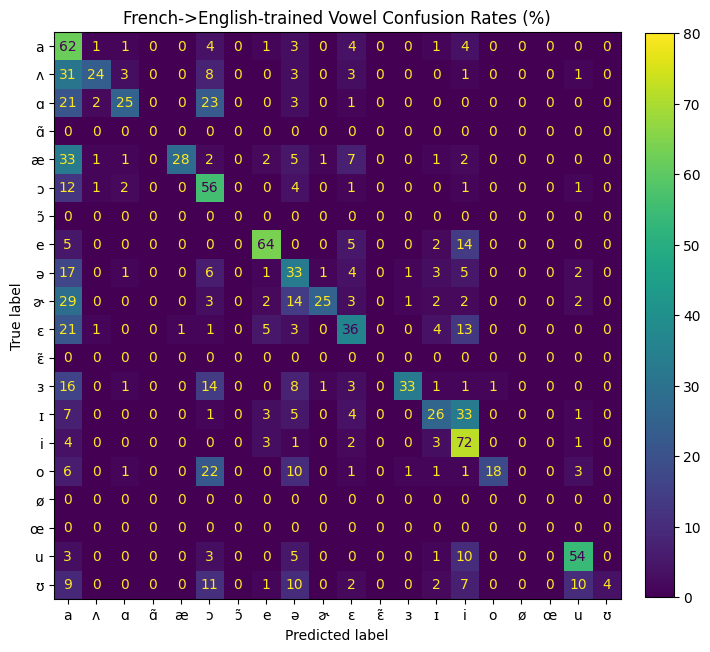

In [55]:
plot_confusions(fren_confusions, vowel_rows, monophthongs, "French->English-trained Vowel")

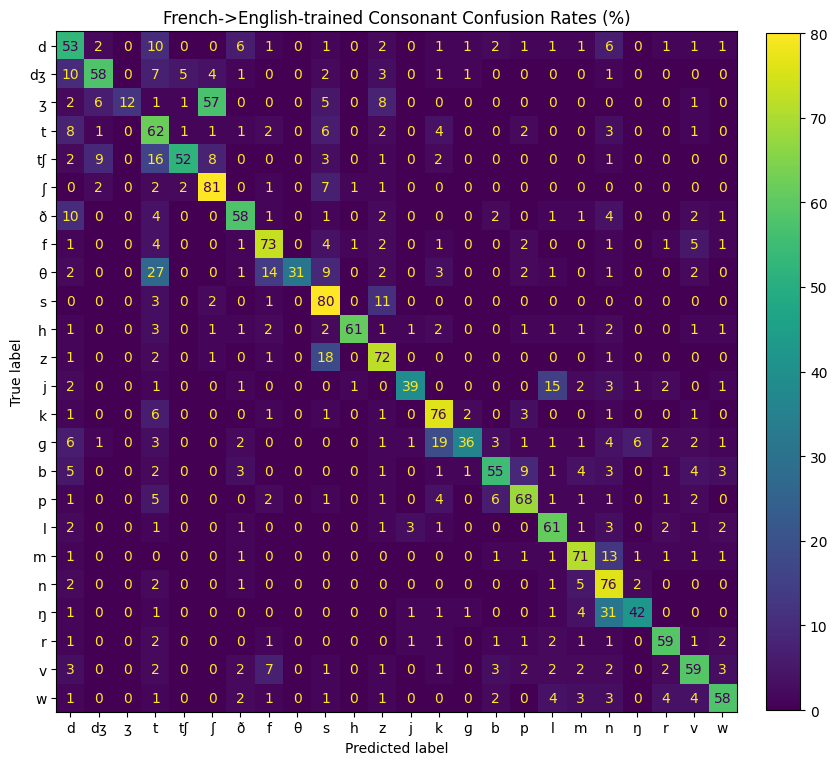

In [56]:
plot_confusions(fren_confusions, conso_rows, consonants, "French->English-trained Consonant")

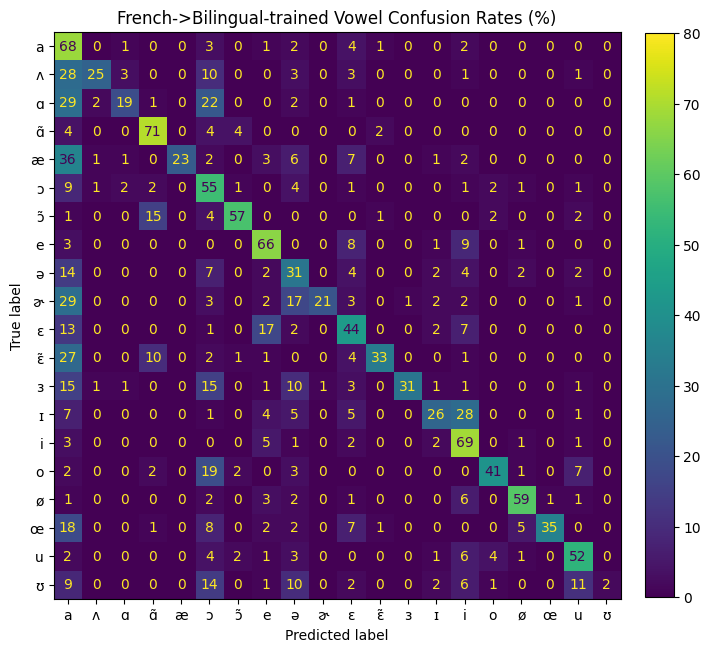

In [57]:
plot_confusions(frbi_confusions, vowel_rows, monophthongs, "French->Bilingual-trained Vowel")

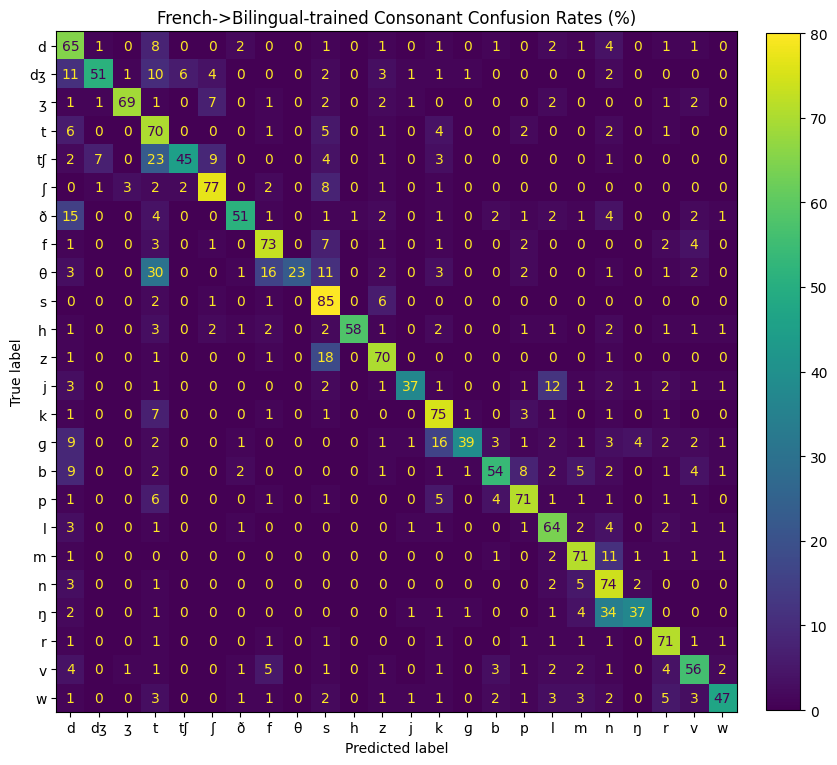

In [58]:
plot_confusions(frbi_confusions, conso_rows, consonants, "French->Bilingual-trained Consonant")

## Compute UMAP based on FR->FR (french) phonemes only

We compute a dimensionality reduction using UMAP to use for our distance metrics. We do this using only french phonemes on our FR trained model.

In [59]:
print(fr_phonemes)

{'s', 'ɔ', 'd', 'r', 'ɑ̃', 'o', 'a', 'm', 'ɛ̃', 't', 'u', 'dʒ', 'œ', 'l', 'ø', 'ɛ', 'e', 'v', 'p', 'b', 'n', 'ʒ', 'ŋ', 'i', 'ə', 'z', 'tʃ', 'f', 'ʃ', 'k', 'ɔ̃', 'ɑ', 'w', 'ɡ', 'j'}


In [63]:
fr_rows = sorted(phone_encoder.encode_sequence(fr_phonemes))
fr_phones = phone_encoder.decode_ndim(fr_rows)
print(fr_phones)

['a', 'b', 'd', 'dʒ', 'e', 'f', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'tʃ', 'u', 'v', 'w', 'z', 'ø', 'ŋ', 'œ', 'ɑ', 'ɑ̃', 'ɔ', 'ɔ̃', 'ə', 'ɛ', 'ɛ̃', 'ɡ', 'ʃ', 'ʒ']


In [87]:
# Load FR->FR model and select fr_rows
model_file = "bilingual_networks/results/20fr20fr/save/CKPT+2025-11-18+17-39-20+00/model.ckpt"
state_dict = torch.load(model_file, map_location="cpu")
fr_phone_mapping = state_dict["phone_out.weight"][fr_rows]

# Normalize length, we'll be using the angle to measure distance
fr_phone_mapping = fr_phone_mapping / fr_phone_mapping.norm(dim=1, keepdim=True)

# Reduce dimensions to 3. Do in two steps to keep mapper for other models
fr_phone_mapper = umap.UMAP(n_components=3, metric='cosine').fit(fr_phone_mapping)
fr_phones_umapped = fr_phone_mapper.transform(fr_phone_mapping)

# Load labels and attach to component vectors
phone2umap = pd.DataFrame([{"phoneme": p, **{f"umap_{i}": c for i, c in enumerate(u)}} for p, u in zip(fr_phones, fr_phones_umapped)])
phone2umap.head()

,phoneme,umap_0,umap_1,umap_2
0,a,8.487523,1.196555,15.992479
1,b,9.464482,3.467048,14.310274
2,d,9.638038,3.323163,13.947033
3,dʒ,10.716124,3.017398,13.435437
4,e,8.436349,1.279568,15.036060


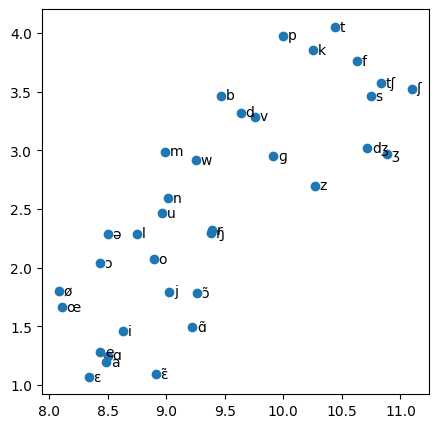

In [88]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()
ax.scatter(phone2umap.umap_0, phone2umap.umap_1)
for i, txt in enumerate(fr_phones):
    ax.text(phone2umap.umap_0[i] + 0.04, phone2umap.umap_1[i], txt, va="center")

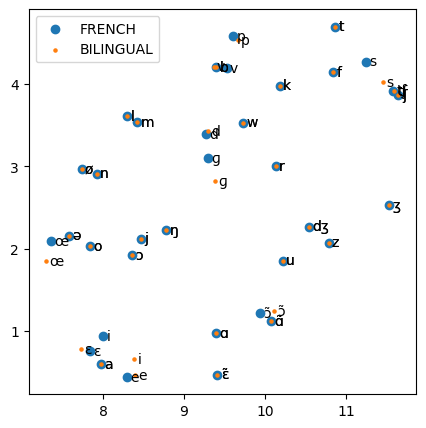

In [94]:
# Check if bilingual model looks similar

# Load FR->Bilingual model and select fr_rows
model_file = "bilingual_networks/results/20fr20fr05en95/save/CKPT+2025-11-18+17-41-19+00/model.ckpt"
state_dict = torch.load(model_file, map_location="cpu")
fr_phone_mapping = state_dict["phone_out.weight"][fr_rows]

# Normalize length, we'll be using the angle to measure distance
fr_phone_mapping = fr_phone_mapping / fr_phone_mapping.norm(dim=1, keepdim=True)

# Use prior mapping to reduce dimensions
fr_phones_umapped = fr_phone_mapper.transform(fr_phone_mapping)
bi_phone2umap = pd.DataFrame([{"phoneme": p, **{f"umap_{i}": c for i, c in enumerate(u)}} for p, u in zip(fr_phones, fr_phones_umapped)])

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()
ax.scatter(phone2umap.umap_0, phone2umap.umap_1)
for i, txt in enumerate(fr_phones):
    ax.text(phone2umap.umap_0[i] + 0.04, phone2umap.umap_1[i], txt, va="center")
ax.scatter(bi_phone2umap.umap_0, bi_phone2umap.umap_1, s=5)
for i, txt in enumerate(fr_phones):
    ax.text(bi_phone2umap.umap_0[i] + 0.04, bi_phone2umap.umap_1[i], txt, va="center")
ax.legend(["FRENCH", "BILINGUAL"])

In [103]:
# Load FR->FR model and select fr_rows
model_file = "bilingual_networks/results/20fr20fr/save/CKPT+2025-11-18+17-39-20+00/model.ckpt"
state_dict = torch.load(model_file, map_location="cpu")
fr_phone_mapping = state_dict["phone_out.weight"][fr_rows]

# Normalize length, we'll be using the angle to measure distance
#fr_phone_mapping = fr_phone_mapping / fr_phone_mapping.norm(dim=1, keepdim=True)

# Reduce dimensions to 3. Do in two steps to keep mapper for other models
fr_phone_pca = PCA(3).fit(fr_phone_mapping)
fr_phones_mapped = fr_phone_pca.transform(fr_phone_mapping)

# Load labels and attach to component vectors
phone2pca = pd.DataFrame([{"phoneme": p, **{f"pca_{i}": c for i, c in enumerate(u)}} for p, u in zip(fr_phones, fr_phones_mapped)])
phone2pca.head()

,phoneme,pca_0,pca_1,pca_2
0,a,-0.866146,-0.498834,-0.144962
1,b,0.596477,1.095309,-0.583375
2,d,0.434017,0.851939,-0.068564
3,dʒ,0.582511,-0.294547,-0.317995
4,e,-0.719415,-0.146350,1.062037


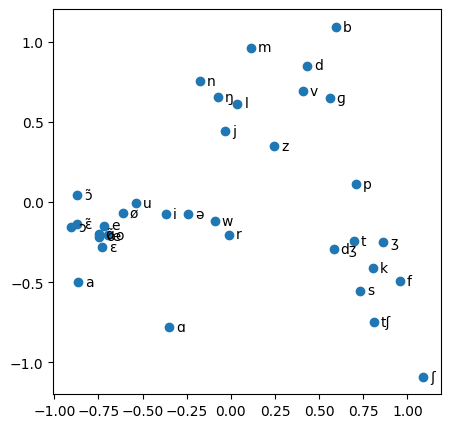

In [104]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()
ax.scatter(phone2pca.pca_0, phone2pca.pca_1)
for i, txt in enumerate(fr_phones):
    ax.text(phone2pca.pca_0[i] + 0.04, phone2pca.pca_1[i], txt, va="center")

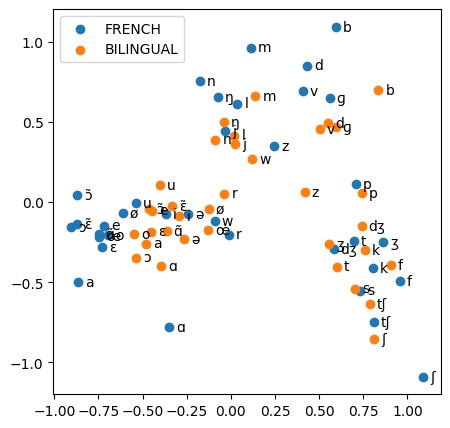

In [106]:
# Check if bilingual model looks similar

# Load FR->Bilingual model and select fr_rows
model_file = "bilingual_networks/results/20fr20fr05en95/save/CKPT+2025-11-18+17-41-19+00/model.ckpt"
state_dict = torch.load(model_file, map_location="cpu")
fr_phone_mapping = state_dict["phone_out.weight"][fr_rows]

# Normalize length, we'll be using the angle to measure distance
#fr_phone_mapping = fr_phone_mapping / fr_phone_mapping.norm(dim=1, keepdim=True)

# Use prior mapping to reduce dimensions
fr_phones_mapped = fr_phone_pca.transform(fr_phone_mapping)
bi_phone2pca = pd.DataFrame([{"phoneme": p, **{f"pca_{i}": c for i, c in enumerate(u)}} for p, u in zip(fr_phones, fr_phones_mapped)])

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()
ax.scatter(phone2pca.pca_0, phone2pca.pca_1)
ax.scatter(bi_phone2pca.pca_0, bi_phone2pca.pca_1)
for i, txt in enumerate(fr_phones):
    ax.text(phone2pca.pca_0[i] + 0.04, phone2pca.pca_1[i], txt, va="center")
    ax.text(bi_phone2pca.pca_0[i] + 0.04, bi_phone2pca.pca_1[i], txt, va="center")
ax.legend(["FRENCH", "BILINGUAL"])

In [116]:
from scipy.spatial.distance import cosine

scores = {}
for i, txt in enumerate(fr_phones):
    scores[txt] = cosine(phone2pca.loc[i, ["pca_0", "pca_1", "pca_2"]].to_numpy(dtype=float), bi_phone2pca.loc[i, ["pca_0", "pca_1", "pca_2"]].to_numpy(dtype=float))

scores

{'a': 0.001952360849458934,
 'b': 0.05788976343786645,
 'd': 0.0956687198890308,
 'dʒ': 0.15218900928208956,
 'e': 0.001904078879238713,
 'f': 0.010576080518487907,
 'i': 0.0024778598632270166,
 'j': 0.019350732629320855,
 'k': 0.004855027492137065,
 'l': 0.17686536974139377,
 'm': 0.029279817847031486,
 'n': 0.030054117170418948,
 'o': 0.00631057870196905,
 'p': 0.0031529836866965866,
 'r': 0.6466998226719913,
 's': 0.02684874919097191,
 't': 0.04875829128742226,
 'tʃ': 0.07451501671614091,
 'u': 0.06578192369823144,
 'v': 0.0968698509545699,
 'w': 0.7525504049386598,
 'z': 0.19334360960884311,
 'ø': 0.04275797844544538,
 'ŋ': 0.024249872258336302,
 'œ': 0.209135291556942,
 'ɑ': 0.05862380981274273,
 'ɑ̃': 0.03699394789501664,
 'ɔ': 0.05535462312389494,
 'ɔ̃': 0.02206797000237881,
 'ə': 0.08566015793117443,
 'ɛ': 0.0015019238647023814,
 'ɛ̃': 0.03672522897568353,
 'ɡ': 0.018536729094852378,
 'ʃ': 0.00037483030278306906,
 'ʒ': 0.05425927469814784}

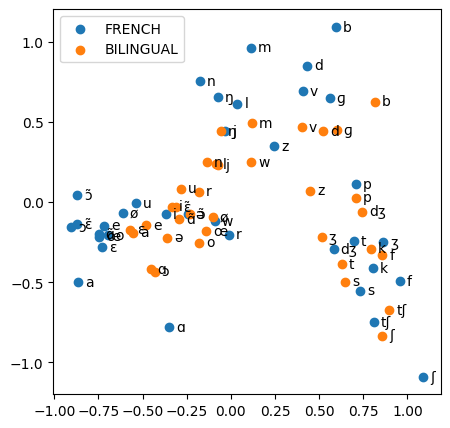

In [117]:
# Try the lower FR percent
model_file = "bilingual_networks/results/20fr20fr01en99/save/CKPT+2025-11-18+17-28-50+00/model.ckpt"
state_dict = torch.load(model_file, map_location="cpu")
fr_phone_mapping = state_dict["phone_out.weight"][fr_rows]

# Normalize length, we'll be using the angle to measure distance
#fr_phone_mapping = fr_phone_mapping / fr_phone_mapping.norm(dim=1, keepdim=True)

# Use prior mapping to reduce dimensions
fr_phones_mapped = fr_phone_pca.transform(fr_phone_mapping)
bi_phone2pca = pd.DataFrame([{"phoneme": p, **{f"pca_{i}": c for i, c in enumerate(u)}} for p, u in zip(fr_phones, fr_phones_mapped)])

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()
ax.scatter(phone2pca.pca_0, phone2pca.pca_1)
ax.scatter(bi_phone2pca.pca_0, bi_phone2pca.pca_1)
for i, txt in enumerate(fr_phones):
    ax.text(phone2pca.pca_0[i] + 0.04, phone2pca.pca_1[i], txt, va="center")
    ax.text(bi_phone2pca.pca_0[i] + 0.04, bi_phone2pca.pca_1[i], txt, va="center")
ax.legend(["FRENCH", "BILINGUAL"])

In [118]:
scores = {}
for i, txt in enumerate(fr_phones):
    scores[txt] = cosine(phone2pca.loc[i, ["pca_0", "pca_1", "pca_2"]].to_numpy(dtype=float), bi_phone2pca.loc[i, ["pca_0", "pca_1", "pca_2"]].to_numpy(dtype=float))

scores

{'a': 0.02132276675484135,
 'b': 0.07582910152381883,
 'd': 0.08257023327041701,
 'dʒ': 0.1252276718717038,
 'e': 0.047950988491379465,
 'f': 0.03058810478973073,
 'i': 0.008965559219397679,
 'j': 0.005326371596182988,
 'k': 0.012373148098324904,
 'l': 0.0947213606915307,
 'm': 0.06915422603548549,
 'n': 0.09370032520905935,
 'o': 0.11498168422301047,
 'p': 0.0059857117670735205,
 'r': 0.9396977146586791,
 's': 0.04111926637475882,
 't': 0.025430385542125622,
 'tʃ': 0.08429496627503241,
 'u': 0.036401809977531285,
 'v': 0.028761377221452444,
 'w': 0.6557749657333809,
 'z': 0.17681486915393652,
 'ø': 0.09946858115315238,
 'ŋ': 0.039924925921650534,
 'œ': 0.22591576288531479,
 'ɑ': 0.07019067102004295,
 'ɑ̃': 0.042559451014231975,
 'ɔ': 0.1263695750913858,
 'ɔ̃': 0.1743061561540471,
 'ə': 0.03041130482348542,
 'ɛ': 0.010878305556543788,
 'ɛ̃': 0.0222650079928014,
 'ɡ': 0.02653820726987355,
 'ʃ': 0.0001519546239905356,
 'ʒ': 0.053346891944074715}

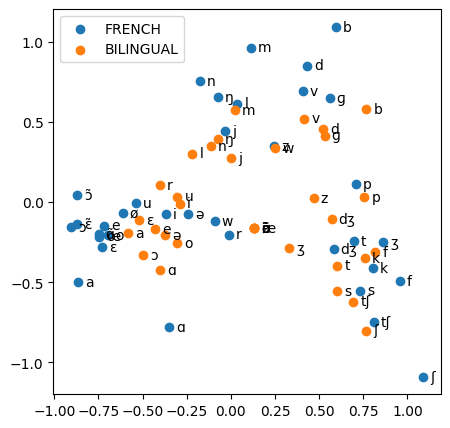

In [119]:
# Try EN only
model_file = "bilingual_networks/results/20fr20en/save/CKPT+2025-11-18+17-57-24+00/model.ckpt"
state_dict = torch.load(model_file, map_location="cpu")
fr_phone_mapping = state_dict["phone_out.weight"][fr_rows]

# Normalize length, we'll be using the angle to measure distance
#fr_phone_mapping = fr_phone_mapping / fr_phone_mapping.norm(dim=1, keepdim=True)

# Use prior mapping to reduce dimensions
fr_phones_mapped = fr_phone_pca.transform(fr_phone_mapping)
bi_phone2pca = pd.DataFrame([{"phoneme": p, **{f"pca_{i}": c for i, c in enumerate(u)}} for p, u in zip(fr_phones, fr_phones_mapped)])

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()
ax.scatter(phone2pca.pca_0, phone2pca.pca_1)
ax.scatter(bi_phone2pca.pca_0, bi_phone2pca.pca_1)
for i, txt in enumerate(fr_phones):
    ax.text(phone2pca.pca_0[i] + 0.04, phone2pca.pca_1[i], txt, va="center")
    ax.text(bi_phone2pca.pca_0[i] + 0.04, bi_phone2pca.pca_1[i], txt, va="center")
ax.legend(["FRENCH", "BILINGUAL"])

In [120]:
scores = {}
for i, txt in enumerate(fr_phones):
    scores[txt] = cosine(phone2pca.loc[i, ["pca_0", "pca_1", "pca_2"]].to_numpy(dtype=float), bi_phone2pca.loc[i, ["pca_0", "pca_1", "pca_2"]].to_numpy(dtype=float))

scores

{'a': 0.01961682912772289,
 'b': 0.08859701518109664,
 'd': 0.08198953368130879,
 'dʒ': 0.1807334073040081,
 'e': 0.13364926229841156,
 'f': 0.028721344437409146,
 'i': 0.0032297336327065107,
 'j': 0.01338986058867031,
 'k': 0.008745323693120532,
 'l': 0.38773448098960916,
 'm': 0.039779853582900815,
 'n': 0.0388543015261833,
 'o': 0.06511360308422542,
 'p': 0.007551969655980595,
 'r': 0.8804859452813,
 's': 0.033427757679951764,
 't': 0.04151530865438613,
 'tʃ': 0.0899589892991105,
 'u': 0.04319713817833215,
 'v': 0.054355510502980264,
 'w': 0.7504877855297359,
 'z': 0.2359137218255527,
 'ø': 1.7192695006945207,
 'ŋ': 0.08672648276320738,
 'œ': 1.3058501712487507,
 'ɑ': 0.05187513211919992,
 'ɑ̃': 0.8838043647633665,
 'ɔ': 0.07492579114256592,
 'ɔ̃': 1.158612430151552,
 'ə': 0.06043026446932198,
 'ɛ': 0.03779915721244509,
 'ɛ̃': 1.3185904149936702,
 'ɡ': 0.025011241612763357,
 'ʃ': 0.0005795296905102276,
 'ʒ': 0.19976142893799564}